# Importación de librerías

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os
import PIL

import glob
import cv2
!pip install split-folders
import splitfolders
import shutil

import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers, Sequential

from sklearn import svm
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import  accuracy_score
from sklearn.metrics import precision_score, recall_score
from sklearn.model_selection import train_test_split

Montar el drive y cargar el dataset.

In [ ]:
# root_dir = r'C:\Users\TU_RUTA_AL_DATASET\EVENODD'
# root_dir = r'C:\Users\TU_RUTA_AL_DATASET\ODD'
# root_dir = r'C:\Users\TU_RUTA_AL_DATASET\EVEN'
# root_dir = r'C:\Users\TU_RUTA_AL_DATASET\GROUP09'
root_dir = r'C:\Users\TU_RUTA_AL_DATASET\KAGGLE'

train_folder = os.path.join(root_dir, "train")
val_folder   = os.path.join(root_dir, "val")
test_folder  = os.path.join(root_dir, "test")

# Parámetros
batch_size= 16
img_height= 224
img_width= 224
dropout_rate = 0.5
epochs= 50
num_classes  = 6

train_ds = tf.keras.utils.image_dataset_from_directory(
  train_folder,
  seed = 123,
  image_size = (img_height, img_width),
  batch_size = batch_size,
)

val_ds = tf.keras.utils.image_dataset_from_directory(
  val_folder,
  seed=123,
  image_size=(img_height, img_width),
  batch_size = batch_size
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_folder,
    seed = 123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

class_names = train_ds.class_names
print(class_names)

Mounted at /content/drive/
Found 6460 files belonging to 6 classes.
Found 1382 files belonging to 6 classes.
Found 1390 files belonging to 6 classes.
['cups', 'forks', 'glasses', 'knives', 'plates', 'spoons']


Creamos el training, validation y test dataset

Imprimir 9 imágenes del dataset

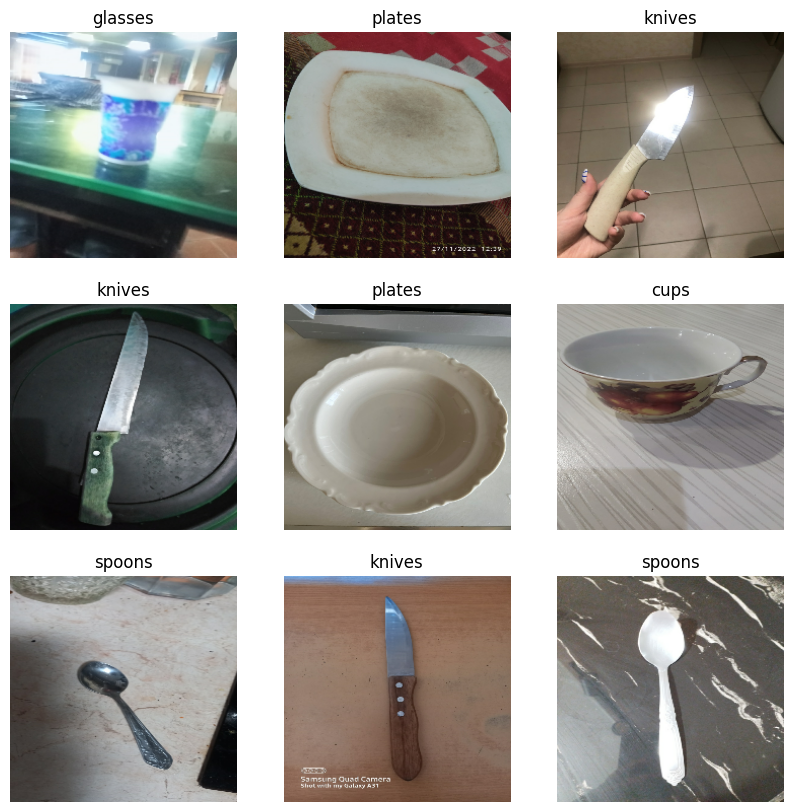

In [3]:
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
  for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i]])
    plt.axis("off")

Arquitectura

In [4]:
import tensorflow as tf

class SparseF1Score(tf.keras.metrics.F1Score):
    def update_state(self, y_true, y_pred, sample_weight=None):
        y_true = tf.cast(y_true, tf.int32) # tipo int32
        y_true = tf.reshape(y_true, [-1]) # aplanar a 1D
        num_classes = tf.shape(y_pred)[-1] # número de clases desde y_pred
        y_true_one_hot = tf.one_hot(y_true, depth=num_classes) # convertir a One-Hot
        return super().update_state(y_true_one_hot, y_pred, sample_weight) # pasar los datos al F1Score original

In [ ]:
class BaselineCNN():
  def __init__(self, input_shape, num_classes):
    self.model = Sequential()

    # preprocesado
    self.model.add(layers.Rescaling(1./255, input_shape=(img_height, img_width, 3)))

    # data Augumentation
    self.model.add(layers.RandomFlip("horizontal"))
    self.model.add(layers.RandomRotation(0.1))
    self.model.add(layers.RandomZoom(0.1))
    self.model.add(layers.RandomContrast(0.1))

    # capas convolucionales
    # bloque 1
    self.model.add(layers.Conv2D(32, (3,3), padding='same', kernel_regularizer=regularizers.l2(1e-5)))
    self.model.add(layers.BatchNormalization())
    self.model.add(layers.Activation('relu'))
    self.model.add(layers.Conv2D(32, (3,3), padding='same', kernel_regularizer=regularizers.l2(1e-5)))
    self.model.add(layers.BatchNormalization())
    self.model.add(layers.Activation('relu'))
    self.model.add(layers.MaxPooling2D((2, 2)))
    self.model.add(layers.Dropout(0.2))

    # bloque 2
    self.model.add(layers.Conv2D(64, (3,3),
                                 padding='same',
                                 kernel_regularizer=regularizers.l2(1e-5)))
    self.model.add(layers.BatchNormalization())
    self.model.add(layers.Activation('relu'))
    self.model.add(layers.Conv2D(64, (3,3),
                                 padding='same',
                                 kernel_regularizer=regularizers.l2(1e-5)))
    self.model.add(layers.BatchNormalization())
    self.model.add(layers.Activation('relu'))
    self.model.add(layers.MaxPooling2D((2, 2)))
    self.model.add(layers.Dropout(0.2))

    #bloque 3
    self.model.add(layers.Conv2D(128, (3,3),
                                 padding='same',
                                 kernel_regularizer=regularizers.l2(1e-5)))
    self.model.add(layers.BatchNormalization())
    self.model.add(layers.Activation('relu'))
    self.model.add(layers.Conv2D(128, (3,3),
                                 padding='same',
                                 kernel_regularizer=regularizers.l2(1e-5)))
    self.model.add(layers.BatchNormalization())
    self.model.add(layers.Activation('relu'))
    self.model.add(layers.MaxPooling2D((2, 2)))
    self.model.add(layers.Dropout(0.25))

    # bloque 4
    self.model.add(layers.Conv2D(256, (3,3),
                                 padding='same',
                                 kernel_regularizer=regularizers.l2(1e-5)))
    self.model.add(layers.BatchNormalization())
    self.model.add(layers.Activation('relu'))
    self.model.add(layers.GlobalAveragePooling2D())

    # clasificador
    self.model.add(layers.Dense(256, kernel_regularizer=regularizers.l2(1e-5)))
    self.model.add(layers.BatchNormalization())
    self.model.add(layers.Activation('relu'))
    # self.model.add(layers.Dropout(0.15))

    self.model.add(layers.Dense(128, kernel_regularizer=regularizers.l2(1e-5)))
    self.model.add(layers.BatchNormalization())
    self.model.add(layers.Activation('relu'))
    self.model.add(layers.Dropout(dropout_rate * 0.5))
    self.model.add(layers.Dense(num_classes, activation='softmax'))

    self.model.summary()

  def train(self):
    # learning rate WarmUp + Cosine Decay
    lr_schedule = tf.keras.optimizers.schedules.CosineDecayRestarts(
        initial_learning_rate=1e-3,
        first_decay_steps=404 * 3,
        t_mul=2.0,
        m_mul=0.9
    )
    self.model.compile(
        optimizer=tf.keras.optimizers.AdamW(
            learning_rate=lr_schedule,
            weight_decay=1e-4
        ),
        loss=tf.keras.losses.SparseCategoricalCrossentropy(),
        metrics=['accuracy', SparseF1Score(average='weighted', name='f1_score')]
    )

  def fit_model(self):
    callbacks = [
        tf.keras.callbacks.EarlyStopping(
            monitor='val_f1_score',
            patience=5,
            restore_best_weights=True,
            mode='max'
        ),
        tf.keras.callbacks.ModelCheckpoint(
            'best_model.keras',
            monitor='val_f1_score',
            save_best_only=True,
            mode='max'
        )
    ]

    self.history = self.model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=epochs,
        callbacks=callbacks
    )

  def plots(self):
    acc = self.history.history['accuracy']
    val_acc = self.history.history['val_accuracy']

    loss = self.history.history['loss']
    val_loss = self.history.history['val_loss']

    epochs_range = range(epochs)

    plt.figure(figsize=(8, 8))
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.legend(loc='lower right')
    plt.title('Training and Validation Accuracy')

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.legend(loc='upper right')
    plt.title('Training and Validation Loss')
    plt.grid(True)

  def get_predictions(self, dataset):
      y_true, y_pred, images_list = [], [], []
      for images, labels in dataset:
          preds = self.model.predict(images, verbose=0)
          y_pred.extend(np.argmax(preds, axis=1))
          y_true.extend(labels.numpy())
          images_list.extend(images.numpy())
      return np.array(y_true), np.array(y_pred), np.array(images_list)

  def plot_confusion_matrix(self, y_true, y_pred, class_names):
      cm = confusion_matrix(y_true, y_pred)
      cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)

      fig, ax = plt.subplots(figsize=(8, 6))

      sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
                  xticklabels=class_names, yticklabels=class_names, ax=ax)
      ax.set_title('Confusion Matrix (normalized)')
      ax.set_ylabel('True label')
      ax.set_xlabel('Predicted label')

      plt.tight_layout()
      plt.savefig('confusion_matrix.png', dpi=120)
      plt.show()


  def plot_misclassified(self, y_true, y_pred, images, class_names, n=12):
      wrong_idx = np.where(y_true != y_pred)[0]
      print(f'Total mal clasificadas: {len(wrong_idx)} / {len(y_true)}')

      show = wrong_idx[:n]
      cols = 4
      rows = int(np.ceil(len(show) / cols))

      fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 4))
      axes = axes.flatten()

      for i, idx in enumerate(show):
          img = images[idx].astype('uint8')
          axes[i].imshow(img)
          axes[i].set_title(
              f'True: {class_names[y_true[idx]]}\nPred: {class_names[y_pred[idx]]}',
              color='red', fontsize=10)
          axes[i].axis('off')

      for j in range(i + 1, len(axes)):
          axes[j].axis('off')

      plt.suptitle(f'Imágenes mal clasificadas', fontsize=13)
      plt.tight_layout()
      plt.savefig(f'misclassified.png', dpi=120)
      plt.show()

  def evaluate(self):
      print("\n── Evaluación en Test ──")
      ts = test_ds
      results = self.model.evaluate(ts, verbose=1)
      for name, val in zip(self.model.metrics_names, results):
          print(f"  {name}: {val:.4f}")



Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_2 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip_2 (RandomFlip)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_2               │ (None, 224, 224, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom_2 (RandomZoom)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_contrast_2               │ (None, 224, 224, 3)    │             0 │
│ (RandomContrast)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_18 (Activation)      │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_19 (Activation)      │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_20          │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_20 (Activation)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_21          │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_21 (Activation)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 56, 56, 128)    │        73,85

 Total params: 685,990 (2.62 MB)

 Trainable params: 683,814 (2.61 MB)

 Non-trainable params: 2,176 (8.50 KB)

Epoch 1/50
404/404 ━━━━━━━━━━━━━━━━━━━━ 105s 236ms/step - accuracy: 0.2525 - f1_score: 0.2418 - loss: 1.8079 - val_accuracy: 0.1751 - val_f1_score: 0.1403 - val_loss: 1.9659
Epoch 2/50
404/404 ━━━━━━━━━━━━━━━━━━━━ 130s 208ms/step - accuracy: 0.2762 - f1_score: 0.2566 - loss: 1.7318 - val_accuracy: 0.1918 - val_f1_score: 0.1184 - val_loss: 2.0297
Epoch 3/50
404/404 ━━━━━━━━━━━━━━━━━━━━ 85s 209ms/step - accuracy: 0.3128 - f1_score: 0.2857 - loss: 1.6354 - val_accuracy: 0.2786 - val_f1_score: 0.2408 - val_loss: 1.7259
Epoch 4/50
404/404 ━━━━━━━━━━━━━━━━━━━━ 141s 208ms/step - accuracy: 0.2963 - f1_score: 0.2720 - loss: 1.6663 - val_accuracy: 0.3205 - val_f1_score: 0.2813 - val_loss: 1.6693
Epoch 5/50
404/404 ━━━━━━━━━━━━━━━━━━━━ 85s 209ms/step - accuracy: 0.3074 - f1_score: 0.2787 - loss: 1.6360 - val_accuracy: 0.2576 - val_f1_score: 0.2009 - val_loss: 1.8283
Epoch 6/50
404/404 ━━━━━━━━━━━━━━━━━━━━ 141s 208ms/step - accuracy: 0.3257 - f1_score: 0.2995 - loss: 1.5752 - val_accuracy: 0.2041 

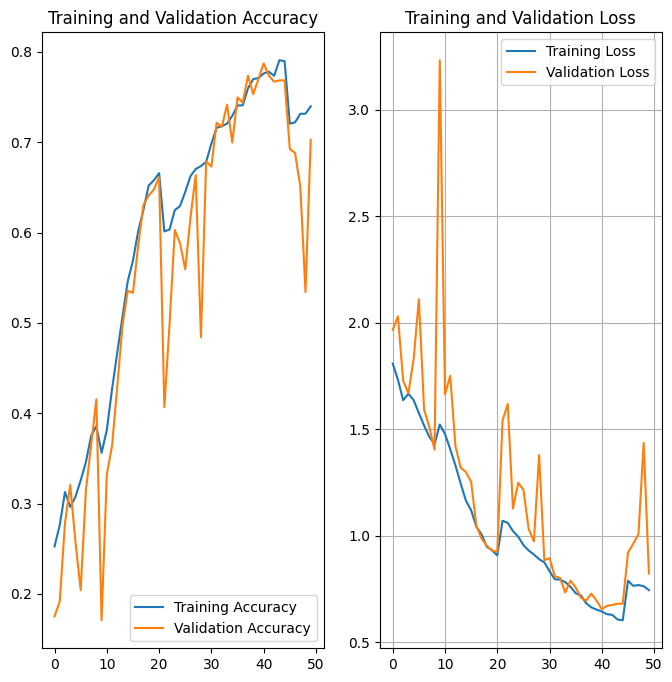

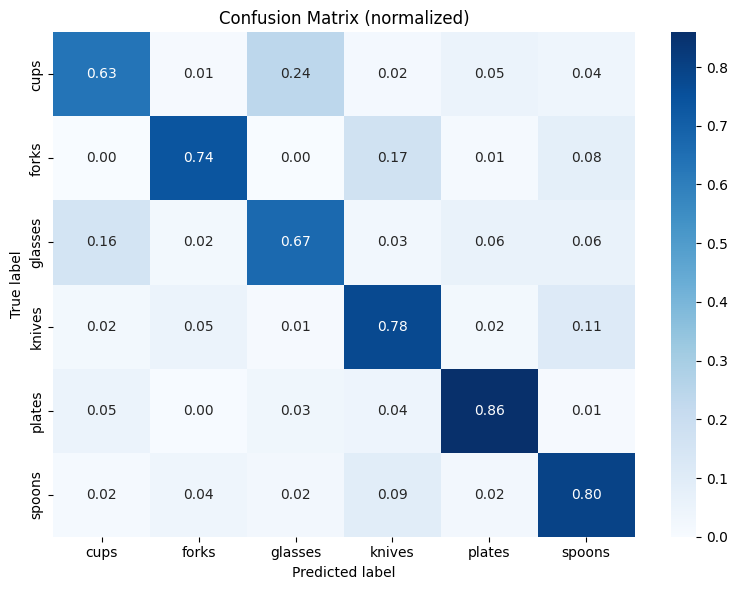

Total mal clasificadas: 349 / 1390


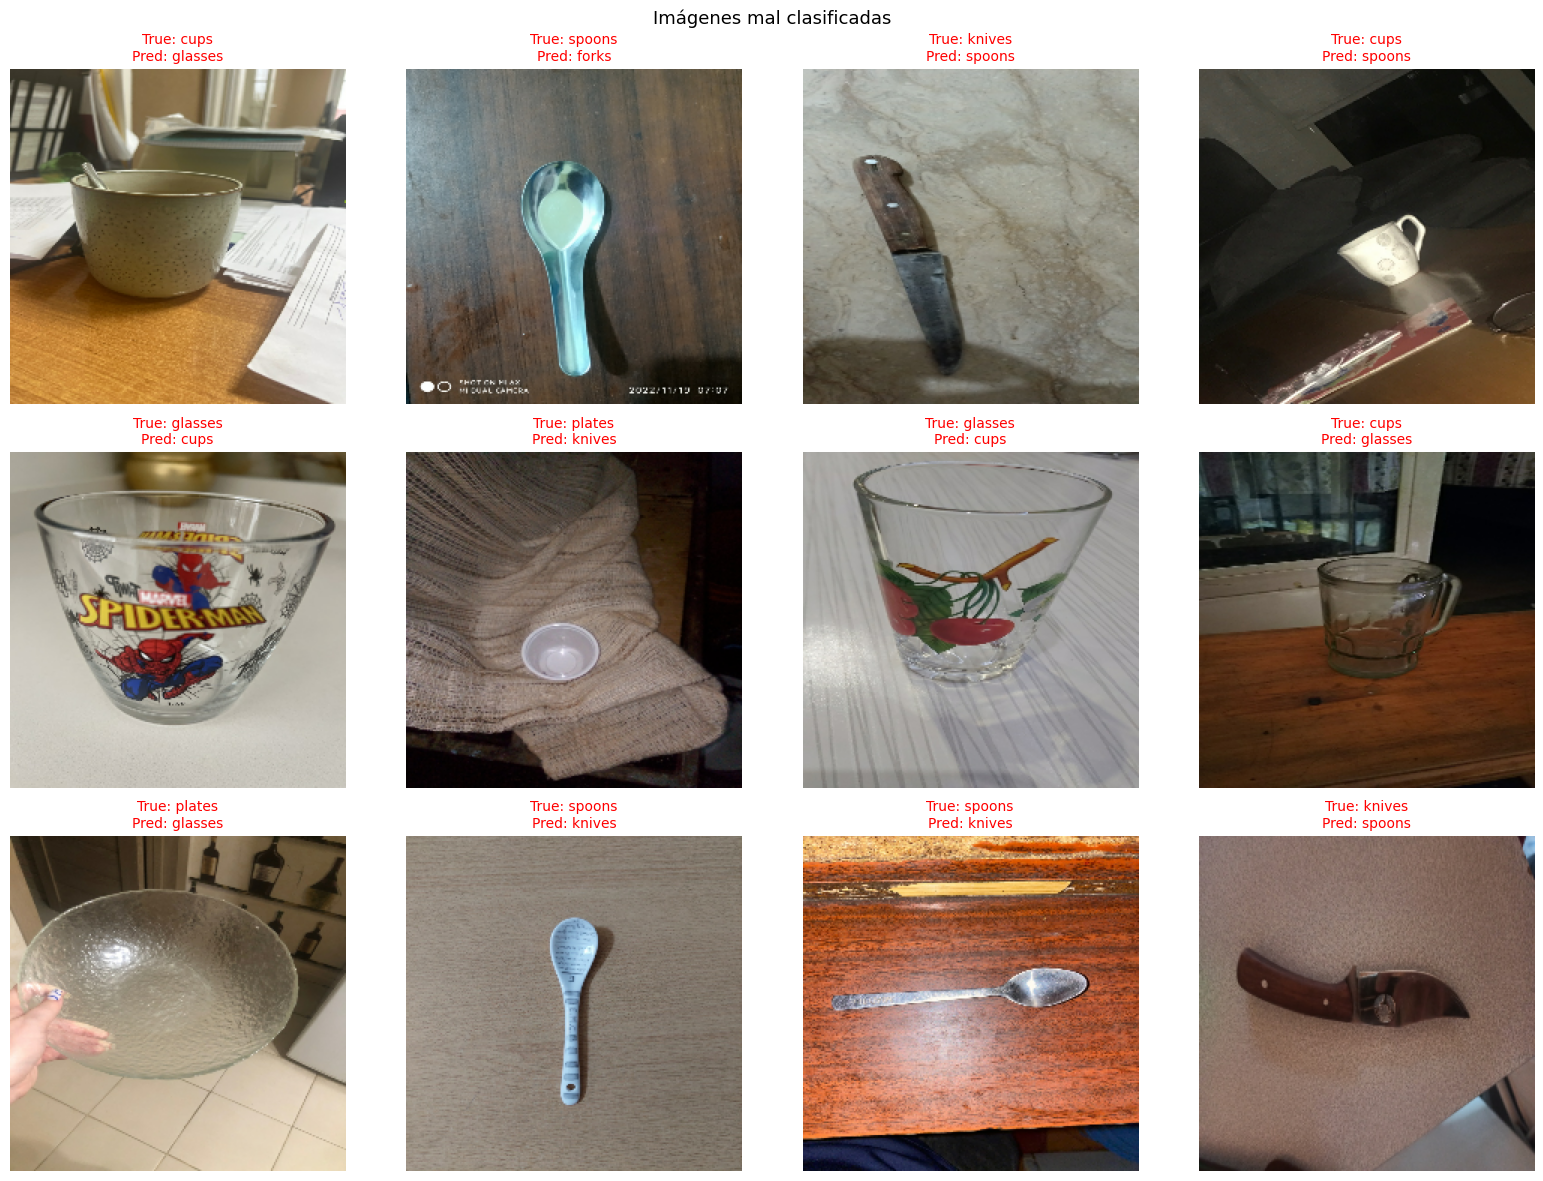

In [8]:
if __name__ == '__main__':
    model = BaselineCNN(input_shape=(224, 224, 3), num_classes=6)
    model.train()
    model.fit_model()
    model.plots()
    model.evaluate()
    y_true, y_pred, images_arr = model.get_predictions(test_ds)
    model.plot_confusion_matrix(y_true, y_pred, class_names)
    model.plot_misclassified(y_true, y_pred, images_arr, class_names, n=12)